<a href="https://colab.research.google.com/github/sungfeliks/Lightweight-Mixture-of-Experts-with-Knowledge-Distillation-Vision-Language-Model/blob/main/04_student_mobilenetv3_small_sparse_top2_moe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Environment and Configuration**

## **Installing dependencies**

In [1]:
!pip -q install \
    albumentations==1.4.7 \
    scikit-learn \
    opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 5.3 MB/s eta 0:00:00


## **Import, seed and runtime**

In [29]:
import gc
import json
import os
import random
import shutil
import time
import zipfile

from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    roc_auc_score,
    recall_score,
)
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm


SEED = 42


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

USE_AMP = DEVICE.type == "cuda"

print("PyTorch version    :", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device             :", DEVICE)
print("AMP enabled        :", USE_AMP)

if torch.cuda.is_available():
    print(
        "GPU                :",
        torch.cuda.get_device_name(0),
    )

PyTorch version    : 2.11.0+cu128
Torchvision version: 0.26.0+cu128
Device             : cuda
AMP enabled        : True
GPU                : Tesla T4


## **Mount Google Drive**

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## **Path configuration**

In [4]:
DRIVE_PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Research"
)

CSV_DIR = (
    DRIVE_PROJECT_ROOT
    / "processed"
)

DATASET_DIR = (
    DRIVE_PROJECT_ROOT
    / "datasets"
)

DATASET_ZIP_PATH = (
    DATASET_DIR
    / "cbis_ddsm_awsaf.zip"
)

TRAIN_CSV_PATH = (
    CSV_DIR
    / "cbis_train.csv"
)

VAL_CSV_PATH = (
    CSV_DIR
    / "cbis_val.csv"
)

ALL_CSV_PATH = (
    CSV_DIR
    / "cbis_all.csv"
)

LOCAL_DATA_PARENT = Path("/content")

CBIS_ROOT = (
    LOCAL_DATA_PARENT
    / "cbis_ddsm_awsaf"
)

JPEG_DIR = (
    CBIS_ROOT
    / "jpeg"
)

OUTPUT_DIR = (
    DRIVE_PROJECT_ROOT
    / "outputs"
    / "student_mobilenetv3_small_sparse_top2_moe"
)

CHECKPOINT_DIR = (
    OUTPUT_DIR
    / "checkpoints"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BEST_MOE_PATH = (
    CHECKPOINT_DIR
    / "mobilenetv3_small_sparse_top2_moe_best.pt"
)

LAST_MOE_PATH = (
    CHECKPOINT_DIR
    / "mobilenetv3_small_sparse_top2_moe_last.pt"
)

MOE_HISTORY_PATH = (
    OUTPUT_DIR
    / "mobilenetv3_small_sparse_top2_moe_history.csv"
)

print("Output directory:", OUTPUT_DIR)
print("Best checkpoint :", BEST_MOE_PATH)
print("Last checkpoint :", LAST_MOE_PATH)

Output directory: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe
Best checkpoint : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/checkpoints/mobilenetv3_small_sparse_top2_moe_best.pt
Last checkpoint : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/checkpoints/mobilenetv3_small_sparse_top2_moe_last.pt


## **Extracting the dataset to the local runtime**

In [5]:
if not TRAIN_CSV_PATH.exists():
    raise FileNotFoundError(
        f"Train CSV not found: {TRAIN_CSV_PATH}"
    )

if not VAL_CSV_PATH.exists():
    raise FileNotFoundError(
        f"Validation CSV not found: {VAL_CSV_PATH}"
    )

if not JPEG_DIR.exists():
    if not DATASET_ZIP_PATH.exists():
        raise FileNotFoundError(
            f"ZIP dataset not found: "
            f"{DATASET_ZIP_PATH}"
        )

    print("Extracting dataset to /content...")

    with zipfile.ZipFile(
        DATASET_ZIP_PATH,
        "r",
    ) as zip_file:
        zip_file.extractall(
            CBIS_ROOT
        )

    print("Dataset extraction completed.")
else:
    print("Dataset is already available locally.")

Extracting dataset to /content...
Dataset extraction completed.


# **Student Dataset**

## **Upload CSV and verify the split**

In [6]:
train_df = pd.read_csv(
    TRAIN_CSV_PATH
)

val_df = pd.read_csv(
    VAL_CSV_PATH
)

print("Train shape     :", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTrain columns:")
print(train_df.columns.tolist())

print("\nTrain label distribution:")
print(
    train_df["cancer"]
    .value_counts()
    .sort_index()
)

print("\nValidation label distribution:")
print(
    val_df["cancer"]
    .value_counts()
    .sort_index()
)

Train shape     : (2482, 5)
Validation shape: (621, 5)

Train columns:
['image_path', 'patient_id', 'left or right breast', 'image view', 'cancer']

Train label distribution:
cancer
0    1394
1    1088
Name: count, dtype: int64

Validation label distribution:
cancer
0    334
1    287
Name: count, dtype: int64


**Set the ‘patient’ column automatically**

In [7]:
patient_column_candidates = [
    "patient_id",
    "patient",
    "PatientID",
    "patientID",
]

PATIENT_COLUMN = next(
    (
        column
        for column
        in patient_column_candidates
        if column in train_df.columns
    ),
    None,
)

if PATIENT_COLUMN is None:
    raise KeyError(
        "Kolom patient tidak ditemukan."
    )

required_columns = {
    "image_path",
    "cancer",
    PATIENT_COLUMN,
}

missing_train_columns = (
    required_columns
    - set(train_df.columns)
)

missing_val_columns = (
    required_columns
    - set(val_df.columns)
)

if missing_train_columns:
    raise KeyError(
        f"Missing train columns: "
        f"{missing_train_columns}"
    )

if missing_val_columns:
    raise KeyError(
        f"Missing validation columns: "
        f"{missing_val_columns}"
    )

train_patients = set(
    train_df[PATIENT_COLUMN].astype(str)
)

val_patients = set(
    val_df[PATIENT_COLUMN].astype(str)
)

patient_overlap = (
    train_patients & val_patients
)

print("Patient column :", PATIENT_COLUMN)
print("Train patients :", len(train_patients))
print("Val patients   :", len(val_patients))
print("Patient overlap:", len(patient_overlap))

assert len(patient_overlap) == 0

print(
    "Patient-level split verification successful."
)

Patient column : patient_id
Train patients : 1252
Val patients   : 314
Patient overlap: 0
Patient-level split verification successful.


## **Resolve image path**

In [8]:
def resolve_image_path(raw_path):
    raw_path = str(raw_path)

    direct_path = Path(raw_path)

    if direct_path.exists():
        return direct_path

    normalized_path = raw_path.replace(
        "\\",
        "/",
    )

    path_parts = [
        part
        for part in normalized_path.split("/")
        if part
    ]

    if "jpeg" in path_parts:
        jpeg_index = path_parts.index("jpeg")

        candidate = (
            CBIS_ROOT
            / Path(
                *path_parts[jpeg_index:]
            )
        )

        if candidate.exists():
            return candidate

    if "cbis_ddsm_awsaf" in path_parts:
        root_index = path_parts.index(
            "cbis_ddsm_awsaf"
        )

        candidate = (
            LOCAL_DATA_PARENT
            / Path(
                *path_parts[root_index:]
            )
        )

        if candidate.exists():
            return candidate

    candidate = (
        JPEG_DIR
        / Path(normalized_path).name
    )

    return candidate

**Verify the entire path**

In [9]:
train_resolved_paths = (
    train_df["image_path"]
    .map(resolve_image_path)
)

val_resolved_paths = (
    val_df["image_path"]
    .map(resolve_image_path)
)

missing_train_paths = [
    path
    for path in train_resolved_paths
    if not path.exists()
]

missing_val_paths = [
    path
    for path in val_resolved_paths
    if not path.exists()
]

print(
    "Missing train images:",
    len(missing_train_paths),
)
print(
    "Missing validation images:",
    len(missing_val_paths),
)

assert len(missing_train_paths) == 0
assert len(missing_val_paths) == 0

print("All image paths were resolved.")

Missing train images: 0
Missing validation images: 0
All image paths were resolved.


## **Student image configuration**

In [10]:
STUDENT_IMAGE_HEIGHT = 512
STUDENT_IMAGE_WIDTH = 320

IMAGENET_MEAN = np.asarray(
    [0.485, 0.456, 0.406],
    dtype=np.float32,
).reshape(1, 1, 3)

IMAGENET_STD = np.asarray(
    [0.229, 0.224, 0.225],
    dtype=np.float32,
).reshape(1, 1, 3)

print(
    "Student input size:",
    (
        STUDENT_IMAGE_HEIGHT,
        STUDENT_IMAGE_WIDTH,
    ),
)

Student input size: (512, 320)


## **Transform Student**

In [11]:
student_train_transform = A.Compose([
    A.Resize(
        height=STUDENT_IMAGE_HEIGHT,
        width=STUDENT_IMAGE_WIDTH,
    ),

    A.Affine(
        scale=(0.97, 1.03),
        translate_percent=(-0.02, 0.02),
        rotate=(-5, 5),
        shear=(-2, 2),
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        p=0.4,
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.08,
        contrast_limit=0.08,
        p=0.3,
    ),
])


student_val_transform = A.Compose([
    A.Resize(
        height=STUDENT_IMAGE_HEIGHT,
        width=STUDENT_IMAGE_WIDTH,
    ),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:34: UserWarning: Argument 'border_mode' is not valid and will be ignored.
  warn(
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:34: UserWarning: Argument 'value' is not valid and will be ignored.
  warn(


## **Dataset class**

In [12]:
class CBISStudentDataset(Dataset):
    def __init__(
        self,
        dataframe,
        transform,
        patient_column,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform
        self.patient_column = patient_column

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = resolve_image_path(
            row["image_path"]
        )

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = np.asarray(image)

        transformed = self.transform(
            image=image
        )

        image = transformed["image"].astype(
            np.float32
        )

        image_min = image.min()
        image_max = image.max()

        image = (
            image - image_min
        ) / (
            image_max
            - image_min
            + 1e-8
        )

        image = (
            image - IMAGENET_MEAN
        ) / IMAGENET_STD

        image = np.transpose(
            image,
            (2, 0, 1),
        )

        image = torch.from_numpy(
            np.ascontiguousarray(image)
        ).float()

        label = torch.tensor(
            float(row["cancer"]),
            dtype=torch.float32,
        )

        return {
            "images": image,
            "labels": label,
            "path": str(image_path),
            "patient": str(
                row[self.patient_column]
            ),
        }

## **Dataset and DataLoader**

In [13]:
STUDENT_BATCH_SIZE = 16
NUM_WORKERS = 2


student_train_dataset = CBISStudentDataset(
    dataframe=train_df,
    transform=student_train_transform,
    patient_column=PATIENT_COLUMN,
)

student_val_dataset = CBISStudentDataset(
    dataframe=val_df,
    transform=student_val_transform,
    patient_column=PATIENT_COLUMN,
)


student_train_loader = DataLoader(
    student_train_dataset,
    batch_size=STUDENT_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    drop_last=False,
)


student_val_loader = DataLoader(
    student_val_dataset,
    batch_size=STUDENT_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=USE_AMP,
    persistent_workers=(
        NUM_WORKERS > 0
    ),
    drop_last=False,
)


print(
    "Train samples     :",
    len(student_train_dataset),
)
print(
    "Validation samples:",
    len(student_val_dataset),
)
print(
    "Train batches     :",
    len(student_train_loader),
)
print(
    "Validation batches:",
    len(student_val_loader),
)

Train samples     : 2482
Validation samples: 621
Train batches     : 156
Validation batches: 39


## **Batch sanity check**

In [14]:
student_batch = next(
    iter(student_train_loader)
)

student_images = student_batch[
    "images"
]

student_labels = student_batch[
    "labels"
]

print(
    "Images:",
    student_images.shape,
    student_images.dtype,
)

print(
    "Labels:",
    student_labels.shape,
    student_labels.dtype,
)

print(
    "Image minimum:",
    student_images.min().item(),
)

print(
    "Image maximum:",
    student_images.max().item(),
)

print(
    "All finite:",
    torch.isfinite(
        student_images
    ).all().item(),
)

print(
    "Labels:",
    student_labels.numpy(),
)

assert student_images.shape[1:] == (
    3,
    STUDENT_IMAGE_HEIGHT,
    STUDENT_IMAGE_WIDTH,
)

assert torch.isfinite(
    student_images
).all()

assert set(
    student_labels.numpy().tolist()
).issubset({0.0, 1.0})

Images: torch.Size([16, 3, 512, 320]) torch.float32
Labels: torch.Size([16]) torch.float32
Image minimum: -2.1179039478302
Image maximum: 2.640000104904175
All finite: True
Labels: [1. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0.]


## **Visualisation of student images**

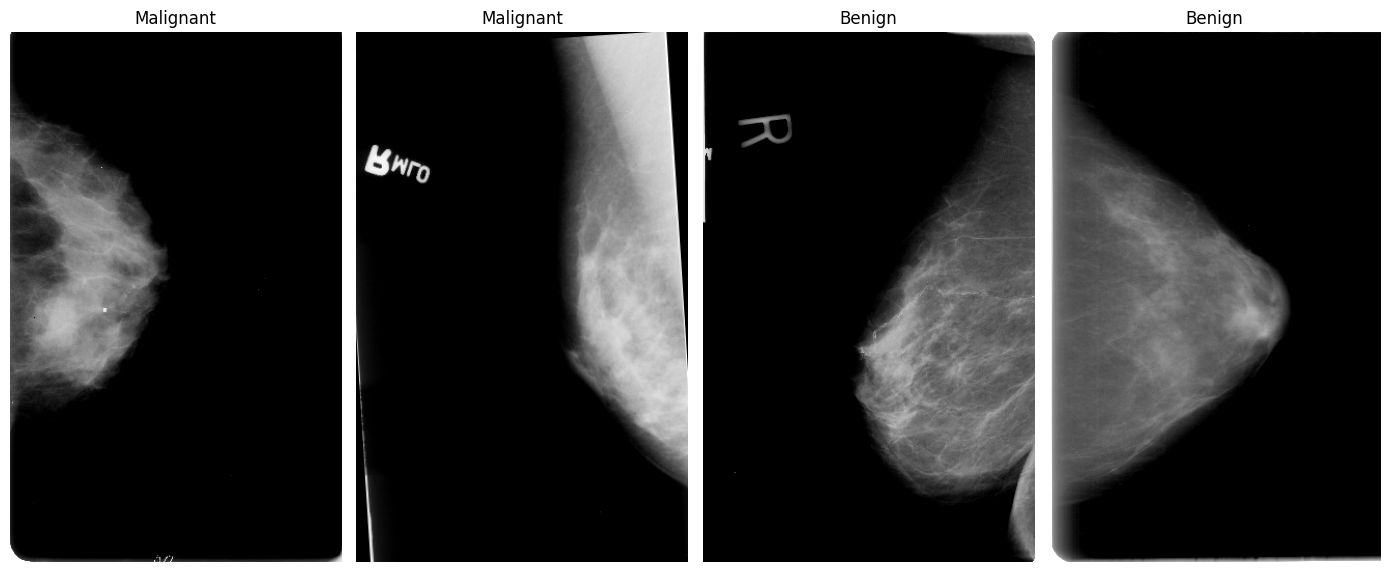

In [15]:
def denormalize_student_image(
    image_tensor,
):
    image = (
        image_tensor
        .detach()
        .cpu()
        .numpy()
    )

    image = np.transpose(
        image,
        (1, 2, 0),
    )

    image = (
        image * IMAGENET_STD
        + IMAGENET_MEAN
    )

    image = np.clip(
        image,
        0,
        1,
    )

    return image


figure, axes = plt.subplots(
    1,
    4,
    figsize=(14, 6),
)

for index, axis in enumerate(axes):
    image = denormalize_student_image(
        student_images[index]
    )

    label = int(
        student_labels[index].item()
    )

    axis.imshow(
        image,
        cmap="gray",
    )

    axis.set_title(
        "Malignant"
        if label == 1
        else "Benign"
    )

    axis.axis("off")

plt.tight_layout()
plt.show()

# **Sparse Top-2 MoE**

## **Import pretrained MobileNetV3-Small**

In [16]:
import math

from torchvision.models import (
    MobileNet_V3_Small_Weights,
    mobilenet_v3_small,
)

## **Expert network**

In [17]:
class BinaryExpert(nn.Module):
    def __init__(
        self,
        input_dim=576,
        hidden_dim=128,
        dropout=0.2,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                hidden_dim,
            ),
            nn.Hardswish(),
            nn.Dropout(dropout),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )

    def forward(self, features):
        return self.network(features)

## **Sparse Top-2 MoE head**

In [18]:
class SparseTop2MoEHead(nn.Module):
    def __init__(
        self,
        input_dim=576,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
        eps=1e-8,
    ):
        super().__init__()

        if top_k > num_experts:
            raise ValueError(
                "top_k cannot exceed num_experts."
            )

        self.input_dim = input_dim
        self.num_experts = num_experts
        self.top_k = top_k
        self.eps = eps

        self.router = nn.Sequential(
            nn.Linear(
                input_dim,
                router_hidden_dim,
            ),
            nn.Hardswish(),
            nn.Dropout(router_dropout),
            nn.Linear(
                router_hidden_dim,
                num_experts,
            ),
        )

        self.experts = nn.ModuleList([
            BinaryExpert(
                input_dim=input_dim,
                hidden_dim=expert_hidden_dim,
                dropout=expert_dropout,
            )
            for _ in range(num_experts)
        ])

        # Generate an initial routing that is approximately uniform,
        # but avoids values that are exactly identical.
        nn.init.normal_(
            self.router[-1].weight,
            mean=0.0,
            std=0.01,
        )

        nn.init.zeros_(
            self.router[-1].bias
        )

    def forward(self, features):
        router_logits = self.router(
            features
        )

        router_probabilities = (
            torch.softmax(
                router_logits,
                dim=1,
            )
        )

        (
            topk_probabilities,
            topk_indices,
        ) = torch.topk(
            router_probabilities,
            k=self.top_k,
            dim=1,
        )

        # Re-normalisation is carried out only amongst selected experts.
        topk_probabilities = (
            topk_probabilities
            / topk_probabilities.sum(
                dim=1,
                keepdim=True,
            ).clamp_min(self.eps)
        )

        sparse_gates = torch.zeros_like(
            router_probabilities
        ).scatter(
            dim=1,
            index=topk_indices,
            src=topk_probabilities,
        )

        expert_logits = torch.cat(
            [
                expert(features)
                for expert in self.experts
            ],
            dim=1,
        )

        combined_logits = (
            sparse_gates
            * expert_logits
        ).sum(
            dim=1,
            keepdim=True,
        )

        # Differentiable load-balancing loss.
        mean_router_probability = (
            router_probabilities
            .float()
            .mean(dim=0)
        )

        balance_loss = (
            self.num_experts
            * torch.sum(
                mean_router_probability ** 2
            )
            - 1.0
        )

        # Expert selection ratio based on hard Top-K.
        hard_assignments = torch.zeros_like(
            router_probabilities
        ).scatter(
            dim=1,
            index=topk_indices,
            value=1.0,
        )

        expert_usage = (
            hard_assignments
            .float()
            .sum(dim=0)
            / (
                features.size(0)
                * self.top_k
            )
        )

        normalized_router_entropy = (
            -(
                router_probabilities.float()
                * torch.log(
                    router_probabilities
                    .float()
                    .clamp_min(self.eps)
                )
            )
            .sum(dim=1)
            .mean()
            / math.log(self.num_experts)
        )

        return {
            "logits": combined_logits,
            "expert_logits": expert_logits,
            "router_logits": router_logits,
            "router_probabilities": (
                router_probabilities
            ),
            "sparse_gates": sparse_gates,
            "topk_indices": topk_indices,
            "expert_usage": expert_usage,
            "balance_loss": balance_loss,
            "router_entropy": (
                normalized_router_entropy
            ),
        }

# **MobileNetV3-Small + MoE**

## **Model Definition**

In [19]:
class MobileNetV3SmallSparseMoE(nn.Module):
    def __init__(
        self,
        pretrained=True,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
    ):
        super().__init__()

        weights = (
            MobileNet_V3_Small_Weights
            .IMAGENET1K_V1
            if pretrained
            else None
        )

        backbone = mobilenet_v3_small(
            weights=weights
        )

        self.features = backbone.features

        self.avgpool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.feature_dim = (
            backbone.classifier[0]
            .in_features
        )

        self.num_experts = num_experts
        self.top_k = top_k

        self.moe_head = SparseTop2MoEHead(
            input_dim=self.feature_dim,
            num_experts=num_experts,
            top_k=top_k,
            expert_hidden_dim=(
                expert_hidden_dim
            ),
            router_hidden_dim=(
                router_hidden_dim
            ),
            expert_dropout=(
                expert_dropout
            ),
            router_dropout=(
                router_dropout
            ),
        )

    def encode(self, images):
        raw_features = self.features(
            images
        )

        pooled_features = self.avgpool(
            raw_features
        )

        pooled_features = torch.flatten(
            pooled_features,
            start_dim=1,
        )

        return (
            pooled_features,
            raw_features,
        )

    def forward(
        self,
        images,
        return_features=False,
    ):
        (
            pooled_features,
            raw_features,
        ) = self.encode(images)

        moe_output = self.moe_head(
            pooled_features
        )

        output = {
            **moe_output,
            "pooled_features": (
                pooled_features
            ),
        }

        if return_features:
            output["raw_features"] = (
                raw_features
            )

        return output

## **Build Model**

In [20]:
moe_student = (
    MobileNetV3SmallSparseMoE(
        pretrained=True,
        num_experts=3,
        top_k=2,
        expert_hidden_dim=128,
        router_hidden_dim=128,
        expert_dropout=0.2,
        router_dropout=0.1,
    )
)

moe_student = moe_student.to(
    DEVICE
)

print(moe_student)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 140MB/s]

MobileNetV3SmallSparseMoE(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel

## **Parameters Summary**

In [21]:
moe_total_parameters = sum(
    parameter.numel()
    for parameter
    in moe_student.parameters()
)

moe_trainable_parameters = sum(
    parameter.numel()
    for parameter
    in moe_student.parameters()
    if parameter.requires_grad
)

moe_backbone_parameters = sum(
    parameter.numel()
    for parameter
    in moe_student.features.parameters()
)

moe_router_parameters = sum(
    parameter.numel()
    for parameter
    in moe_student.moe_head.router.parameters()
)

moe_expert_parameters = sum(
    parameter.numel()
    for parameter
    in moe_student.moe_head.experts.parameters()
)

print(
    "Feature dimension :",
    moe_student.feature_dim,
)

print(
    "Number of experts :",
    moe_student.num_experts,
)

print(
    "Active experts    :",
    moe_student.top_k,
)

print(
    "Total parameters  :",
    f"{moe_total_parameters:,}",
)

print(
    "Trainable params  :",
    f"{moe_trainable_parameters:,}",
)

print(
    "Backbone params   :",
    f"{moe_backbone_parameters:,}",
)

print(
    "Router params     :",
    f"{moe_router_parameters:,}",
)

print(
    "Expert params     :",
    f"{moe_expert_parameters:,}",
)

assert moe_student.feature_dim == 576
assert moe_student.num_experts == 3
assert moe_student.top_k == 2
assert (
    moe_total_parameters
    == moe_trainable_parameters
)

print(
    "Sparse Top-2 MoE configuration verified."
)

Feature dimension : 576
Number of experts : 3
Active experts    : 2
Total parameters  : 1,223,206
Trainable params  : 1,223,206
Backbone params   : 927,008
Router params     : 74,243
Expert params     : 221,955
Sparse Top-2 MoE configuration verified.


# **Forward dan Routing Sanity Check**

## **Get one batch**

In [22]:
moe_batch = next(
    iter(student_train_loader)
)

moe_images = (
    moe_batch["images"][:8]
    .to(
        DEVICE,
        non_blocking=True,
    )
)

moe_labels = (
    moe_batch["labels"][:8]
    .to(
        DEVICE,
        non_blocking=True,
    )
    .float()
    .view(-1)
)

print("Images:", moe_images.shape)
print("Labels:", moe_labels.shape)

Images: torch.Size([8, 3, 512, 320])
Labels: torch.Size([8])


## **Forward pass**

In [23]:
moe_student.train()

with torch.autocast(
    device_type=DEVICE.type,
    dtype=torch.float16,
    enabled=USE_AMP,
):
    moe_output = moe_student(
        moe_images,
        return_features=True,
    )

print(
    "Logits              :",
    moe_output["logits"].shape,
)

print(
    "Expert logits       :",
    moe_output[
        "expert_logits"
    ].shape,
)

print(
    "Router probabilities:",
    moe_output[
        "router_probabilities"
    ].shape,
)

print(
    "Sparse gates        :",
    moe_output[
        "sparse_gates"
    ].shape,
)

print(
    "Top-k indices       :",
    moe_output[
        "topk_indices"
    ].shape,
)

print(
    "Pooled features     :",
    moe_output[
        "pooled_features"
    ].shape,
)

print(
    "Raw features        :",
    moe_output[
        "raw_features"
    ].shape,
)

Logits              : torch.Size([8, 1])
Expert logits       : torch.Size([8, 3])
Router probabilities: torch.Size([8, 3])
Sparse gates        : torch.Size([8, 3])
Top-k indices       : torch.Size([8, 2])
Pooled features     : torch.Size([8, 576])
Raw features        : torch.Size([8, 576, 16, 10])


## **Top-2 routing verification**

In [24]:
router_probabilities = (
    moe_output[
        "router_probabilities"
    ]
)

sparse_gates = (
    moe_output[
        "sparse_gates"
    ]
)

active_experts_per_sample = (
    sparse_gates > 0
).sum(dim=1)

print(
    "Router probability sums:",
    router_probabilities
    .sum(dim=1)
    .detach()
    .float()
    .cpu()
    .numpy()
    .round(4),
)

print(
    "Sparse gate sums:",
    sparse_gates
    .sum(dim=1)
    .detach()
    .float()
    .cpu()
    .numpy()
    .round(4),
)

print(
    "Active experts per sample:",
    active_experts_per_sample
    .detach()
    .cpu()
    .numpy(),
)

print(
    "Top-2 expert indices:"
)

print(
    moe_output["topk_indices"]
    .detach()
    .cpu()
    .numpy()
)

print(
    "Expert usage:",
    moe_output["expert_usage"]
    .detach()
    .float()
    .cpu()
    .numpy()
    .round(4),
)

print(
    "Balance loss:",
    float(
        moe_output[
            "balance_loss"
        ].detach().cpu()
    ),
)

print(
    "Normalized router entropy:",
    float(
        moe_output[
            "router_entropy"
        ].detach().cpu()
    ),
)

assert torch.allclose(
    router_probabilities.sum(dim=1),
    torch.ones(
        router_probabilities.size(0),
        device=DEVICE,
        dtype=router_probabilities.dtype,
    ),
    atol=1e-3,
)

assert torch.allclose(
    sparse_gates.sum(dim=1),
    torch.ones(
        sparse_gates.size(0),
        device=DEVICE,
        dtype=sparse_gates.dtype,
    ),
    atol=1e-3,
)

assert torch.all(
    active_experts_per_sample == 2
)

assert torch.isfinite(
    moe_output["balance_loss"]
)

print(
    "Sparse Top-2 routing verification succeeded."
)

Router probability sums: [1. 1. 1. 1. 1. 1. 1. 1.]
Sparse gate sums: [1. 1. 1. 1. 1. 1. 1. 1.]
Active experts per sample: [2 2 2 2 2 2 2 2]
Top-2 expert indices:
[[0 2]
 [0 2]
 [2 0]
 [0 2]
 [2 0]
 [0 2]
 [0 2]
 [0 2]]
Expert usage: [0.5 0.  0.5]
Balance loss: 0.00018405914306640625
Normalized router entropy: 0.9999021291732788
Sparse Top-2 routing verification succeeded.


## **BCE and total loss**

In [25]:
MOE_BALANCE_WEIGHT = 0.01
moe_criterion = nn.BCEWithLogitsLoss()

with torch.autocast(
    device_type=DEVICE.type,
    dtype=torch.float16,
    enabled=USE_AMP,
):
    moe_bce_loss = moe_criterion(
        moe_output["logits"].view(-1),
        moe_labels,
    )

    moe_total_loss = (
        moe_bce_loss
        + MOE_BALANCE_WEIGHT
        * moe_output["balance_loss"]
    )

print(
    "BCE loss     :",
    float(
        moe_bce_loss.detach().cpu()
    ),
)

print(
    "Balance loss :",
    float(
        moe_output[
            "balance_loss"
        ].detach().cpu()
    ),
)

print(
    "Total loss   :",
    float(
        moe_total_loss.detach().cpu()
    ),
)

assert torch.isfinite(
    moe_bce_loss
)

assert torch.isfinite(
    moe_total_loss
)

BCE loss     : 0.6648052930831909
Balance loss : 0.00018405914306640625
Total loss   : 0.664807140827179


## **Backward sanity check**

In [26]:
moe_student.zero_grad(
    set_to_none=True
)

moe_total_loss.backward()

backbone_has_gradient = any(
    parameter.grad is not None
    and torch.isfinite(
        parameter.grad
    ).all()
    for parameter
    in moe_student.features.parameters()
)

router_has_gradient = any(
    parameter.grad is not None
    and torch.isfinite(
        parameter.grad
    ).all()
    for parameter
    in moe_student.moe_head.router.parameters()
)

expert_gradient_flags = []

for expert in (
    moe_student.moe_head.experts
):
    has_gradient = any(
        parameter.grad is not None
        and torch.isfinite(
            parameter.grad
        ).all()
        for parameter
        in expert.parameters()
    )

    expert_gradient_flags.append(
        has_gradient
    )

print(
    "Backbone gradient:",
    backbone_has_gradient,
)

print(
    "Router gradient  :",
    router_has_gradient,
)

print(
    "Expert gradients :",
    expert_gradient_flags,
)

print(
    "Experts receiving gradient:",
    sum(expert_gradient_flags),
)

assert backbone_has_gradient is True
assert router_has_gradient is True

# Top-2 routing ensures that at least two experts
# can be involved in a single batch.
assert sum(expert_gradient_flags) >= 2

print(
    "Sparse MoE forward and backward "
    "sanity checks succeeded."
)

Backbone gradient: True
Router gradient  : True
Expert gradients : [True, True, True]
Experts receiving gradient: 3
Sparse MoE forward and backward sanity checks succeeded.


In [27]:
def module_gradient_norm(module):
    squared_norm = 0.0
    gradient_found = False

    for parameter in module.parameters():
        if parameter.grad is not None:
            gradient_found = True

            squared_norm += (
                parameter.grad
                .detach()
                .float()
                .pow(2)
                .sum()
                .item()
            )

    if not gradient_found:
        return 0.0

    return squared_norm ** 0.5


backbone_gradient_norm = module_gradient_norm(
    moe_student.features
)

router_gradient_norm = module_gradient_norm(
    moe_student.moe_head.router
)

expert_gradient_norms = [
    module_gradient_norm(expert)
    for expert in moe_student.moe_head.experts
]

effective_expert_gradients = [
    norm > 1e-12
    for norm in expert_gradient_norms
]

print(
    "Backbone gradient norm:",
    backbone_gradient_norm,
)

print(
    "Router gradient norm  :",
    router_gradient_norm,
)

print(
    "Expert gradient norms :",
    expert_gradient_norms,
)

print(
    "Effective expert gradients:",
    effective_expert_gradients,
)

print(
    "Experts with non-zero gradient:",
    sum(effective_expert_gradients),
)

assert backbone_gradient_norm > 0
assert router_gradient_norm > 0
assert sum(effective_expert_gradients) >= 2

print(
    "Sparse MoE effective-gradient "
    "verification succeeded."
)

Backbone gradient norm: 0.44493969997492455
Router gradient norm  : 0.006829451279515769
Expert gradient norms : [0.37624296605819085, 0.0, 0.39901857744245633]
Effective expert gradients: [True, False, True]
Experts with non-zero gradient: 2
Sparse MoE effective-gradient verification succeeded.


## **Clear the temporary tensor**

In [28]:
moe_student.zero_grad(set_to_none=True)

temporary_variables = [
    "moe_batch",
    "moe_images",
    "moe_labels",
    "moe_output",
    "router_probabilities",
    "sparse_gates",
    "active_experts_per_sample",
    "moe_bce_loss",
    "moe_total_loss",
    "backbone_gradient_norm",
    "router_gradient_norm",
    "expert_gradient_norms",
    "effective_expert_gradients",
]

for variable_name in temporary_variables:
    globals().pop(variable_name, None)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

    print(
        "GPU allocated:",
        f"{torch.cuda.memory_allocated() / 1024**3:.3f} GB",
    )

    print(
        "GPU reserved :",
        f"{torch.cuda.memory_reserved() / 1024**3:.3f} GB",
    )

print("MoE sanity tensors cleaned.")

GPU allocated: 0.022 GB
GPU reserved : 0.047 GB
MoE sanity tensors cleaned.


# **MobileNetV3-Small Sparse Top-2 MoE Training**

## **Reset the seed and rebuild the model**

In [30]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm


MOE_SEED = 42


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


set_global_seed(MOE_SEED)

del moe_student

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


moe_student = MobileNetV3SmallSparseMoE(
    pretrained=True,
    num_experts=3,
    top_k=2,
    expert_hidden_dim=128,
    router_hidden_dim=128,
    expert_dropout=0.2,
    router_dropout=0.1,
).to(DEVICE)

print("Fresh MoE model created.")
print("Device            :", DEVICE)
print("Feature dimension :", moe_student.feature_dim)
print("Number of experts :", moe_student.num_experts)
print("Active experts    :", moe_student.top_k)

Fresh MoE model created.
Device            : cuda
Feature dimension : 576
Number of experts : 3
Active experts    : 2


## **Training configuration**

In [31]:
MOE_EPOCHS = 12

MOE_BACKBONE_LR = 1e-4
MOE_HEAD_LR = 5e-4

MOE_WEIGHT_DECAY = 1e-4
MOE_BALANCE_WEIGHT = 0.01

MOE_MAX_GRAD_NORM = 5.0
MOE_EARLY_STOPPING_PATIENCE = 4
MOE_MIN_AUC_IMPROVEMENT = 1e-4

MOE_DEFAULT_THRESHOLD = 0.5

MOE_SCHEDULER_FACTOR = 0.5
MOE_SCHEDULER_PATIENCE = 1
MOE_MIN_LR = 1e-7

RESUME_MOE_TRAINING = True

print("Maximum epochs       :", MOE_EPOCHS)
print("Backbone learning rate:", MOE_BACKBONE_LR)
print("MoE learning rate     :", MOE_HEAD_LR)
print("Balance loss weight   :", MOE_BALANCE_WEIGHT)
print("Early stopping        :", MOE_EARLY_STOPPING_PATIENCE)

Maximum epochs       : 12
Backbone learning rate: 0.0001
MoE learning rate     : 0.0005
Balance loss weight   : 0.01
Early stopping        : 4


## **Loss, optimizer, scheduler, dan AMP scaler**

In [32]:
moe_criterion = nn.BCEWithLogitsLoss()


moe_optimizer = AdamW(
    [
        {
            "params": (
                moe_student.features.parameters()
            ),
            "lr": MOE_BACKBONE_LR,
            "name": "backbone",
        },
        {
            "params": list(
                moe_student.moe_head.router.parameters()
            )
            + list(
                moe_student.moe_head.experts.parameters()
            ),
            "lr": MOE_HEAD_LR,
            "name": "moe_head",
        },
    ],
    weight_decay=MOE_WEIGHT_DECAY,
)


moe_scheduler = ReduceLROnPlateau(
    moe_optimizer,
    mode="max",
    factor=MOE_SCHEDULER_FACTOR,
    patience=MOE_SCHEDULER_PATIENCE,
    min_lr=MOE_MIN_LR,
)


moe_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP,
)


print(
    "Optimizer groups:",
    len(moe_optimizer.param_groups),
)

for index, group in enumerate(
    moe_optimizer.param_groups
):
    print(
        f"Group {index}:",
        group.get("name"),
        "| LR:",
        group["lr"],
    )

print("AMP enabled:", USE_AMP)

Optimizer groups: 2
Group 0: backbone | LR: 0.0001
Group 1: moe_head | LR: 0.0005
AMP enabled: True


## **Binary metric calculation function**

In [33]:
def calculate_binary_metrics(
    labels,
    probabilities,
    threshold=0.5,
):
    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    predictions = (
        probabilities >= threshold
    ).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    if np.unique(labels).size == 2:
        roc_auc = roc_auc_score(
            labels,
            probabilities,
        )

        average_precision = (
            average_precision_score(
                labels,
                probabilities,
            )
        )
    else:
        roc_auc = np.nan
        average_precision = np.nan

    return {
        "roc_auc": float(roc_auc),
        "average_precision": float(
            average_precision
        ),
        "accuracy": float(
            accuracy_score(
                labels,
                predictions,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                labels,
                predictions,
            )
        ),
        "precision": float(
            precision_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),
        "sensitivity": float(
            sensitivity
        ),
        "specificity": float(
            specificity
        ),
        "f1": float(
            f1_score(
                labels,
                predictions,
                zero_division=0,
            )
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

## **One-epoch metric finalisation function**

In [45]:
def finalize_moe_epoch_metrics(
    all_labels,
    all_probabilities,
    sample_count,
    selection_count,
    total_loss_sum,
    bce_loss_sum,
    balance_loss_sum,
    entropy_sum,
    router_probability_sum,
    expert_selection_counts,
    threshold=0.5,
):
    classification_metrics = (
        calculate_binary_metrics(
            labels=all_labels,
            probabilities=all_probabilities,
            threshold=threshold,
        )
    )

    router_probability_mean = (
        router_probability_sum
        / max(sample_count, 1)
    )

    epoch_router_balance_loss = (
      len(router_probability_mean)
      * np.sum(
          router_probability_mean ** 2
      )
      - 1.0
    )

    expert_usage = (
        expert_selection_counts
        / max(selection_count, 1)
    )

    epoch_metrics = {
        "total_loss": float(
            total_loss_sum
            / max(sample_count, 1)
        ),
        "bce_loss": float(
            bce_loss_sum
            / max(sample_count, 1)
        ),
        "balance_loss": float(
            balance_loss_sum
            / max(sample_count, 1)
        ),
        # Balance based on the average probability
        # across all epochs.
        "epoch_balance_loss": float(
            epoch_router_balance_loss
        ),
        "router_entropy": float(
            entropy_sum
            / max(sample_count, 1)
        ),
        **classification_metrics,
    }

    for expert_index in range(
        len(expert_usage)
    ):
        epoch_metrics[
            f"expert_{expert_index}_usage"
        ] = float(
            expert_usage[expert_index]
        )

        epoch_metrics[
            f"expert_{expert_index}_router_probability"
        ] = float(
            router_probability_mean[
                expert_index
            ]
        )

    return epoch_metrics

## **One-epoch training function**

In [35]:
def train_moe_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    scaler,
    device,
    balance_weight=0.01,
    threshold=0.5,
    max_grad_norm=5.0,
):
    model.train()

    sample_count = 0
    selection_count = 0

    total_loss_sum = 0.0
    bce_loss_sum = 0.0
    balance_loss_sum = 0.0
    entropy_sum = 0.0

    router_probability_sum = np.zeros(
        model.num_experts,
        dtype=np.float64,
    )

    expert_selection_counts = np.zeros(
        model.num_experts,
        dtype=np.int64,
    )

    all_labels = []
    all_probabilities = []

    progress_bar = tqdm(
        data_loader,
        desc="Training MoE",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = (
            batch["labels"]
            .to(
                device,
                non_blocking=True,
            )
            .float()
            .view(-1)
        )

        batch_size = labels.size(0)

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            output = model(images)

            logits = (
                output["logits"]
                .view(-1)
            )

            bce_loss = criterion(
                logits,
                labels,
            )

            balance_loss = (
                output["balance_loss"]
            )

            total_loss = (
                bce_loss
                + balance_weight
                * balance_loss
            )

        scaler.scale(
            total_loss
        ).backward()

        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=max_grad_norm,
        )

        scaler.step(
            optimizer
        )

        scaler.update()

        probabilities = torch.sigmoid(
            logits.detach()
        )

        sample_count += batch_size
        selection_count += (
            batch_size * model.top_k
        )

        total_loss_sum += (
            float(
                total_loss.detach().cpu()
            )
            * batch_size
        )

        bce_loss_sum += (
            float(
                bce_loss.detach().cpu()
            )
            * batch_size
        )

        balance_loss_sum += (
            float(
                balance_loss.detach().cpu()
            )
            * batch_size
        )

        entropy_sum += (
            float(
                output["router_entropy"]
                .detach()
                .cpu()
            )
            * batch_size
        )

        router_probability_sum += (
            output[
                "router_probabilities"
            ]
            .detach()
            .float()
            .sum(dim=0)
            .cpu()
            .numpy()
        )

        batch_selection_counts = (
            torch.bincount(
                output["topk_indices"]
                .detach()
                .reshape(-1)
                .cpu(),
                minlength=model.num_experts,
            )
            .numpy()
        )

        expert_selection_counts += (
            batch_selection_counts
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
            .astype(np.int64)
            .tolist()
        )

        all_probabilities.extend(
            probabilities
            .float()
            .cpu()
            .numpy()
            .tolist()
        )

        progress_bar.set_postfix({
            "loss": (
                total_loss_sum
                / sample_count
            ),
            "bce": (
                bce_loss_sum
                / sample_count
            ),
        })

    return finalize_moe_epoch_metrics(
        all_labels=all_labels,
        all_probabilities=all_probabilities,
        sample_count=sample_count,
        selection_count=selection_count,
        total_loss_sum=total_loss_sum,
        bce_loss_sum=bce_loss_sum,
        balance_loss_sum=balance_loss_sum,
        entropy_sum=entropy_sum,
        router_probability_sum=(
            router_probability_sum
        ),
        expert_selection_counts=(
            expert_selection_counts
        ),
        threshold=threshold,
    )

## **One-epoch validation function**

In [36]:
@torch.inference_mode()
def validate_moe_one_epoch(
    model,
    data_loader,
    criterion,
    device,
    balance_weight=0.01,
    threshold=0.5,
):
    model.eval()

    sample_count = 0
    selection_count = 0

    total_loss_sum = 0.0
    bce_loss_sum = 0.0
    balance_loss_sum = 0.0
    entropy_sum = 0.0

    router_probability_sum = np.zeros(
        model.num_experts,
        dtype=np.float64,
    )

    expert_selection_counts = np.zeros(
        model.num_experts,
        dtype=np.int64,
    )

    all_labels = []
    all_probabilities = []

    progress_bar = tqdm(
        data_loader,
        desc="Validating MoE",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = (
            batch["labels"]
            .to(
                device,
                non_blocking=True,
            )
            .float()
            .view(-1)
        )

        batch_size = labels.size(0)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            output = model(images)

            logits = (
                output["logits"]
                .view(-1)
            )

            bce_loss = criterion(
                logits,
                labels,
            )

            balance_loss = (
                output["balance_loss"]
            )

            total_loss = (
                bce_loss
                + balance_weight
                * balance_loss
            )

        probabilities = torch.sigmoid(
            logits
        )

        sample_count += batch_size
        selection_count += (
            batch_size * model.top_k
        )

        total_loss_sum += (
            float(
                total_loss.detach().cpu()
            )
            * batch_size
        )

        bce_loss_sum += (
            float(
                bce_loss.detach().cpu()
            )
            * batch_size
        )

        balance_loss_sum += (
            float(
                balance_loss.detach().cpu()
            )
            * batch_size
        )

        entropy_sum += (
            float(
                output["router_entropy"]
                .detach()
                .cpu()
            )
            * batch_size
        )

        router_probability_sum += (
            output[
                "router_probabilities"
            ]
            .detach()
            .float()
            .sum(dim=0)
            .cpu()
            .numpy()
        )

        batch_selection_counts = (
            torch.bincount(
                output["topk_indices"]
                .detach()
                .reshape(-1)
                .cpu(),
                minlength=model.num_experts,
            )
            .numpy()
        )

        expert_selection_counts += (
            batch_selection_counts
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
            .astype(np.int64)
            .tolist()
        )

        all_probabilities.extend(
            probabilities
            .float()
            .cpu()
            .numpy()
            .tolist()
        )

    return finalize_moe_epoch_metrics(
        all_labels=all_labels,
        all_probabilities=all_probabilities,
        sample_count=sample_count,
        selection_count=selection_count,
        total_loss_sum=total_loss_sum,
        bce_loss_sum=bce_loss_sum,
        balance_loss_sum=balance_loss_sum,
        entropy_sum=entropy_sum,
        router_probability_sum=(
            router_probability_sum
        ),
        expert_selection_counts=(
            expert_selection_counts
        ),
        threshold=threshold,
    )

## **Training resumption configuration**

In [37]:
moe_start_epoch = 1

moe_history = []

moe_best_val_auc = -np.inf
moe_best_epoch = 0

moe_epochs_without_improvement = 0

moe_cumulative_training_time_seconds = 0.0


if (
    RESUME_MOE_TRAINING
    and LAST_MOE_PATH.exists()
):
    print(
        "Loading last MoE checkpoint:",
        LAST_MOE_PATH,
    )

    resume_checkpoint = torch.load(
        LAST_MOE_PATH,
        map_location=DEVICE,
        weights_only=False,
    )

    moe_student.load_state_dict(
        resume_checkpoint[
            "model_state_dict"
        ],
        strict=True,
    )

    moe_optimizer.load_state_dict(
        resume_checkpoint[
            "optimizer_state_dict"
        ]
    )

    moe_scheduler.load_state_dict(
        resume_checkpoint[
            "scheduler_state_dict"
        ]
    )

    if (
        "scaler_state_dict"
        in resume_checkpoint
    ):
        moe_scaler.load_state_dict(
            resume_checkpoint[
                "scaler_state_dict"
            ]
        )

    completed_epoch = int(
        resume_checkpoint["epoch"]
    )

    moe_start_epoch = (
        completed_epoch + 1
    )

    moe_best_val_auc = float(
        resume_checkpoint.get(
            "best_val_auc",
            -np.inf,
        )
    )

    moe_best_epoch = int(
        resume_checkpoint.get(
            "best_epoch",
            0,
        )
    )

    moe_epochs_without_improvement = int(
        resume_checkpoint.get(
            "epochs_without_improvement",
            0,
        )
    )

    moe_history = list(
        resume_checkpoint.get(
            "history",
            [],
        )
    )

    moe_cumulative_training_time_seconds = float(
        resume_checkpoint.get(
            "cumulative_training_time_seconds",
            0.0,
        )
    )

    print(
        "Training resumed after epoch:",
        completed_epoch,
    )

    print(
        "Next epoch:",
        moe_start_epoch,
    )

    print(
        "Best epoch:",
        moe_best_epoch,
    )

    print(
        "Best validation AUC:",
        f"{moe_best_val_auc:.4f}",
    )

else:
    print(
        "No last checkpoint loaded. "
        "Training starts from epoch 1."
    )

No last checkpoint loaded. Training starts from epoch 1.


## **Main training loop**

In [38]:
if moe_start_epoch > MOE_EPOCHS:
    print(
        "Maximum number of epochs "
        "has already been reached."
    )

else:
    print(
        f"Starting MoE training from "
        f"epoch {moe_start_epoch}."
    )


for epoch in range(
    moe_start_epoch,
    MOE_EPOCHS + 1,
):
    epoch_start_time = time.time()

    current_backbone_lr = (
        moe_optimizer
        .param_groups[0]["lr"]
    )

    current_moe_lr = (
        moe_optimizer
        .param_groups[1]["lr"]
    )

    train_metrics = train_moe_one_epoch(
        model=moe_student,
        data_loader=student_train_loader,
        criterion=moe_criterion,
        optimizer=moe_optimizer,
        scaler=moe_scaler,
        device=DEVICE,
        balance_weight=(
            MOE_BALANCE_WEIGHT
        ),
        threshold=(
            MOE_DEFAULT_THRESHOLD
        ),
        max_grad_norm=(
            MOE_MAX_GRAD_NORM
        ),
    )

    val_metrics = validate_moe_one_epoch(
        model=moe_student,
        data_loader=student_val_loader,
        criterion=moe_criterion,
        device=DEVICE,
        balance_weight=(
            MOE_BALANCE_WEIGHT
        ),
        threshold=(
            MOE_DEFAULT_THRESHOLD
        ),
    )

    epoch_time_seconds = (
        time.time() - epoch_start_time
    )

    moe_cumulative_training_time_seconds += (
        epoch_time_seconds
    )

    epoch_record = {
        "epoch": int(epoch),
        "backbone_lr": float(
            current_backbone_lr
        ),
        "moe_lr": float(
            current_moe_lr
        ),
        "epoch_time_minutes": float(
            epoch_time_seconds / 60
        ),
    }

    for metric_name, metric_value in (
        train_metrics.items()
    ):
        epoch_record[
            f"train_{metric_name}"
        ] = metric_value

    for metric_name, metric_value in (
        val_metrics.items()
    ):
        epoch_record[
            f"val_{metric_name}"
        ] = metric_value

    moe_history.append(
        epoch_record
    )

    val_auc = val_metrics["roc_auc"]

    improved = (
        val_auc
        > moe_best_val_auc
        + MOE_MIN_AUC_IMPROVEMENT
    )

    if improved:
        moe_best_val_auc = float(
            val_auc
        )

        moe_best_epoch = int(
            epoch
        )

        moe_epochs_without_improvement = 0

    else:
        moe_epochs_without_improvement += 1

    # The scheduler is updated based on AUC validation.
    moe_scheduler.step(
        val_auc
    )

    checkpoint_data = {
        "epoch": int(epoch),
        "model_state_dict": (
            moe_student.state_dict()
        ),
        "optimizer_state_dict": (
            moe_optimizer.state_dict()
        ),
        "scheduler_state_dict": (
            moe_scheduler.state_dict()
        ),
        "scaler_state_dict": (
            moe_scaler.state_dict()
        ),
        "best_epoch": int(
            moe_best_epoch
        ),
        "best_val_auc": float(
            moe_best_val_auc
        ),
        "epochs_without_improvement": int(
            moe_epochs_without_improvement
        ),
        "history": moe_history,
        "train_metrics": train_metrics,
        "val_metrics": val_metrics,
        "cumulative_training_time_seconds": float(
            moe_cumulative_training_time_seconds
        ),
        "configuration": {
            "model": (
                "MobileNetV3-Small "
                "Sparse Top-2 MoE"
            ),
            "num_experts": 3,
            "top_k": 2,
            "feature_dim": 576,
            "expert_hidden_dim": 128,
            "router_hidden_dim": 128,
            "balance_weight": (
                MOE_BALANCE_WEIGHT
            ),
            "backbone_initial_lr": (
                MOE_BACKBONE_LR
            ),
            "moe_initial_lr": (
                MOE_HEAD_LR
            ),
            "weight_decay": (
                MOE_WEIGHT_DECAY
            ),
            "default_threshold": (
                MOE_DEFAULT_THRESHOLD
            ),
            "input_size": [512, 320],
            "seed": MOE_SEED,
        },
    }

    # The last checkpoint is always saved.
    torch.save(
        checkpoint_data,
        LAST_MOE_PATH,
    )

    if improved:
        torch.save(
            checkpoint_data,
            BEST_MOE_PATH,
        )

    pd.DataFrame(
        moe_history
    ).to_csv(
        MOE_HISTORY_PATH,
        index=False,
    )

    train_usage = [
        train_metrics[
            f"expert_{index}_usage"
        ]
        for index in range(3)
    ]

    val_usage = [
        val_metrics[
            f"expert_{index}_usage"
        ]
        for index in range(3)
    ]

    print(
        f"Epoch {epoch:02d}/{MOE_EPOCHS} | "
        f"Backbone LR {current_backbone_lr:.2e} | "
        f"MoE LR {current_moe_lr:.2e} | "
        f"Train Loss {train_metrics['total_loss']:.4f} | "
        f"Train AUC {train_metrics['roc_auc']:.4f} | "
        f"Val Loss {val_metrics['total_loss']:.4f} | "
        f"Val AUC {val_metrics['roc_auc']:.4f} | "
        f"Val Sens {val_metrics['sensitivity']:.4f} | "
        f"Val Spec {val_metrics['specificity']:.4f} | "
        f"{epoch_time_seconds / 60:.2f} min"
    )

    print(
        "  Train usage:",
        np.round(
            train_usage,
            4,
        ),
        "| Entropy:",
        f"{train_metrics['router_entropy']:.4f}",
        "| Balance:",
        f"{train_metrics['balance_loss']:.6f}",
    )

    print(
        "  Val usage  :",
        np.round(
            val_usage,
            4,
        ),
        "| Entropy:",
        f"{val_metrics['router_entropy']:.4f}",
        "| Balance:",
        f"{val_metrics['balance_loss']:.6f}",
    )

    if improved:
        print(
            "  ✓ Best MoE checkpoint saved "
            f"(Val AUC: {val_auc:.4f})"
        )
    else:
        print(
            "  No validation AUC improvement "
            f"for "
            f"{moe_epochs_without_improvement} "
            "epoch(s)."
        )

    # Peringatan routing, bukan penghentian training.
    if min(val_usage) < 0.05:
        print(
            "  ⚠ One expert has validation "
            "usage below 5%."
        )

    if (
        val_metrics["router_entropy"]
        < 0.50
    ):
        print(
            "  ⚠ Router entropy is below 0.50; "
            "check possible expert collapse."
        )

    if (
        moe_epochs_without_improvement
        >= MOE_EARLY_STOPPING_PATIENCE
    ):
        print()
        print(
            "Early stopping activated "
            f"at epoch {epoch}."
        )
        break

Starting MoE training from epoch 1.


Training MoE:   0%|          | 0/156 [00:00<?, ?it/s]

Validating MoE:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 01/12 | Backbone LR 1.00e-04 | MoE LR 5.00e-04 | Train Loss 0.6570 | Train AUC 0.6433 | Val Loss 0.6625 | Val AUC 0.6396 | Val Sens 0.1672 | Val Spec 0.8653 | 10.75 min
  Train usage: [0.3926 0.11   0.4974] | Entropy: 0.9857 | Balance: 0.021139
  Val usage  : [0.5 0.  0.5] | Entropy: 0.9698 | Balance: 0.056015
  ✓ Best MoE checkpoint saved (Val AUC: 0.6396)
  ⚠ One expert has validation usage below 5%.


Training MoE:   0%|          | 0/156 [00:00<?, ?it/s]

...

Validating MoE:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 11/12 | Backbone LR 2.50e-05 | MoE LR 1.25e-04 | Train Loss 0.3322 | Train AUC 0.9309 | Val Loss 0.8667 | Val AUC 0.7387 | Val Sens 0.7526 | Val Spec 0.6048 | 8.01 min
  Train usage: [0.2683 0.4202 0.3114] | Entropy: 0.8018 | Balance: 0.046319
  Val usage  : [0.347 0.343 0.31 ] | Entropy: 0.7760 | Balance: 0.139873
  No validation AUC improvement for 3 epoch(s).


Training MoE:   0%|          | 0/156 [00:00<?, ?it/s]

Validating MoE:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 12/12 | Backbone LR 2.50e-05 | MoE LR 1.25e-04 | Train Loss 0.3223 | Train AUC 0.9347 | Val Loss 0.8565 | Val AUC 0.7268 | Val Sens 0.5923 | Val Spec 0.7066 | 7.87 min
  Train usage: [0.2619 0.4251 0.3131] | Entropy: 0.8045 | Balance: 0.038500
  Val usage  : [0.2641 0.3994 0.3366] | Entropy: 0.8217 | Balance: 0.053615
  No validation AUC improvement for 4 epoch(s).

Early stopping activated at epoch 12.


## **Training summary**

In [39]:
moe_training_time_minutes = (
    moe_cumulative_training_time_seconds
    / 60
)

print()
print("MoE training completed.")
print(
    "Best epoch   :",
    moe_best_epoch,
)

print(
    "Best val AUC :",
    f"{moe_best_val_auc:.4f}",
)

print(
    "Training time:",
    f"{moe_training_time_minutes:.2f} minutes",
)

print(
    "Best checkpoint:",
    BEST_MOE_PATH,
)

print(
    "Last checkpoint:",
    LAST_MOE_PATH,
)

print(
    "History CSV:",
    MOE_HISTORY_PATH,
)


MoE training completed.
Best epoch   : 8
Best val AUC : 0.7524
Training time: 98.33 minutes
Best checkpoint: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/checkpoints/mobilenetv3_small_sparse_top2_moe_best.pt
Last checkpoint: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/checkpoints/mobilenetv3_small_sparse_top2_moe_last.pt
History CSV: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/mobilenetv3_small_sparse_top2_moe_history.csv


## **Visualisation of training history**

In [40]:
moe_history_df = pd.DataFrame(
    moe_history
)

display(
    moe_history_df.tail()
)

,epoch,backbone_lr,moe_lr,epoch_time_minutes,train_total_loss,train_bce_loss,train_balance_loss,train_router_entropy,train_roc_auc,train_average_precision,...,val_tn,val_fp,val_fn,val_tp,val_expert_0_usage,val_expert_0_router_probability,val_expert_1_usage,val_expert_1_router_probability,val_expert_2_usage,val_expert_2_router_probability
7,8,0.000050,0.000250,7.924359,0.410872,0.410488,0.038338,0.866489,0.890110,0.858090,...,230,104,97,190,0.279388,0.361440,0.367955,0.251278,0.352657,0.387282
8,9,0.000050,0.000250,7.816020,0.378844,0.378413,0.043102,0.827384,0.908024,0.886431,...,238,96,114,173,0.258454,0.363457,0.397746,0.245743,0.343800,0.390800
9,10,0.000050,0.000250,7.945172,0.365229,0.364749,0.047993,0.795580,0.915258,0.900244,...,175,159,58,229,0.359903,0.508479,0.425926,0.217352,0.214171,0.274169
10,11,0.000025,0.000125,8.009979,0.332236,0.331772,0.046319,0.801771,0.930913,0.915842,...,202,132,71,216,0.347021,0.486285,0.342995,0.209818,0.309984,0.303896
11,12,0.000025,0.000125,7.873372,0.322269,0.321884,0.038500,0.804472,0.934714,0.917430,...,236,98,117,170,0.264090,0.377020,0.399356,0.248850,0.336554,0.374130


**Calculating the epoch-level balance loss**

In [46]:
NUM_EXPERTS = 3

for split in ["train", "val"]:
    router_probability_columns = [
        f"{split}_expert_{expert_index}_router_probability"
        for expert_index in range(NUM_EXPERTS)
    ]

    # Verify that the average probability
    # of routers is approximately one.
    probability_sums = (
        moe_history_df[
            router_probability_columns
        ].sum(axis=1)
    )

    assert np.allclose(
        probability_sums.to_numpy(),
        np.ones(len(probability_sums)),
        atol=1e-4,
    )

    # Balance loss based on the average
    # router probability across all epochs.
    moe_history_df[
        f"{split}_epoch_balance_loss"
    ] = (
        NUM_EXPERTS
        * (
            moe_history_df[
                router_probability_columns
            ] ** 2
        ).sum(axis=1)
        - 1.0
    )


display(
    moe_history_df[
        [
            "epoch",
            "train_balance_loss",
            "train_epoch_balance_loss",
            "val_balance_loss",
            "val_epoch_balance_loss",
        ]
    ].round(6)
)

,epoch,train_balance_loss,train_epoch_balance_loss,val_balance_loss,val_epoch_balance_loss
0,1,0.021139,0.008353,0.056015,0.055578
1,2,0.042171,0.033484,0.034557,0.032336
2,3,0.020559,0.015363,0.014808,0.012985
3,4,0.014507,0.012230,0.014159,0.010804
4,5,0.027665,0.023839,0.022796,0.015885
5,6,0.021033,0.016584,0.034083,0.028351
6,7,0.022532,0.016635,0.168398,0.158391
7,8,0.038338,0.028202,0.046449,0.031301
8,9,0.043102,0.038565,0.052760,0.035646
9,10,0.047993,0.042995,0.161630,0.142885


In [47]:
MOE_ENRICHED_HISTORY_PATH = (
    OUTPUT_DIR
    / "mobilenetv3_small_sparse_top2_moe_history_enriched.csv"
)

moe_history_df.to_csv(
    MOE_ENRICHED_HISTORY_PATH,
    index=False,
)

print(
    "Enriched history saved:",
    MOE_ENRICHED_HISTORY_PATH,
)

Enriched history saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/mobilenetv3_small_sparse_top2_moe_history_enriched.csv


**Loss Curve**

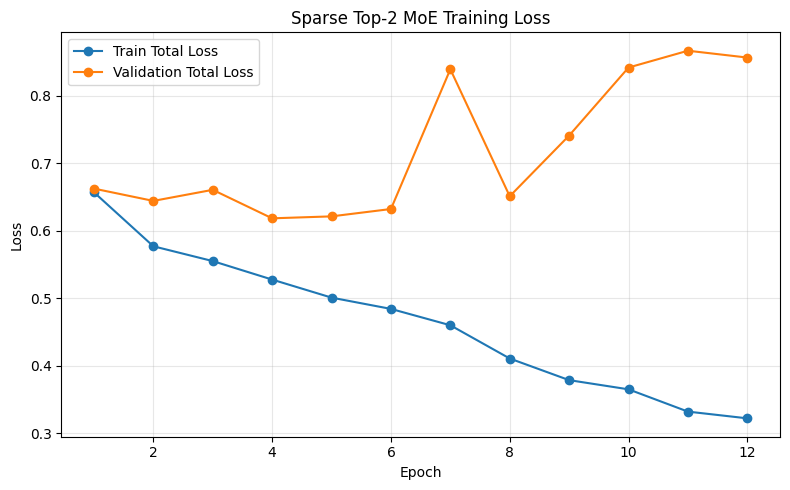

In [41]:
MOE_LOSS_CURVE_PATH = (
    OUTPUT_DIR
    / "moe_training_loss_curve.png"
)

plt.figure(figsize=(8, 5))

plt.plot(
    moe_history_df["epoch"],
    moe_history_df["train_total_loss"],
    marker="o",
    label="Train Total Loss",
)

plt.plot(
    moe_history_df["epoch"],
    moe_history_df["val_total_loss"],
    marker="o",
    label="Validation Total Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sparse Top-2 MoE Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    MOE_LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

**ROC-AUC Curve**

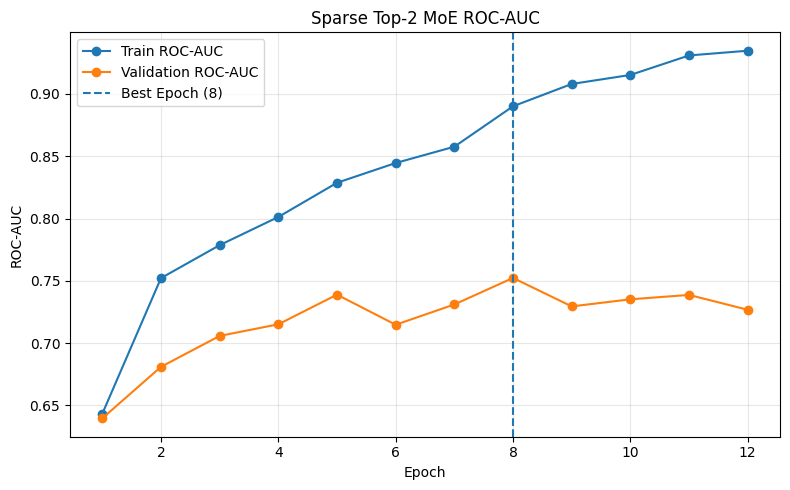

In [42]:
MOE_AUC_CURVE_PATH = (
    OUTPUT_DIR
    / "moe_training_auc_curve.png"
)

plt.figure(figsize=(8, 5))

plt.plot(
    moe_history_df["epoch"],
    moe_history_df["train_roc_auc"],
    marker="o",
    label="Train ROC-AUC",
)

plt.plot(
    moe_history_df["epoch"],
    moe_history_df["val_roc_auc"],
    marker="o",
    label="Validation ROC-AUC",
)

plt.axvline(
    moe_best_epoch,
    linestyle="--",
    label=f"Best Epoch ({moe_best_epoch})",
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Sparse Top-2 MoE ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    MOE_AUC_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

**Expert usage validation**

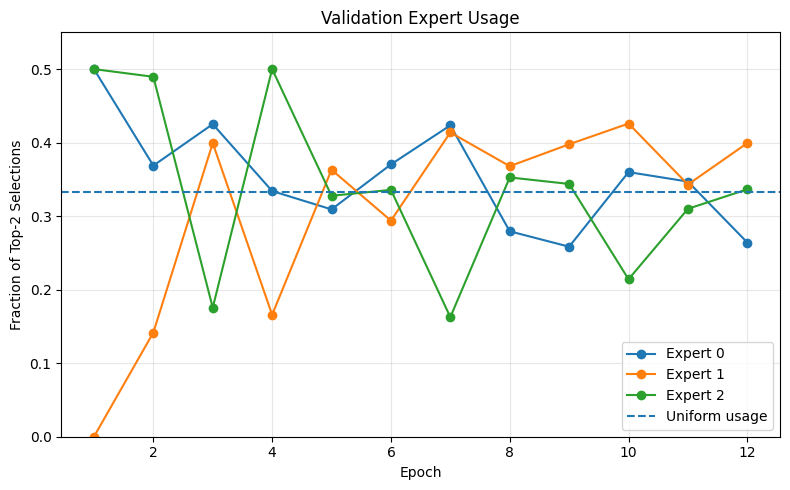

In [43]:
MOE_USAGE_CURVE_PATH = (
    OUTPUT_DIR
    / "moe_validation_expert_usage.png"
)

plt.figure(figsize=(8, 5))

for expert_index in range(3):
    plt.plot(
        moe_history_df["epoch"],
        moe_history_df[
            f"val_expert_{expert_index}_usage"
        ],
        marker="o",
        label=f"Expert {expert_index}",
    )

plt.axhline(
    1 / 3,
    linestyle="--",
    label="Uniform usage",
)

plt.xlabel("Epoch")
plt.ylabel("Fraction of Top-2 Selections")
plt.title("Validation Expert Usage")
plt.ylim(0, 0.55)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    MOE_USAGE_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

**Router entropy and balance loss**

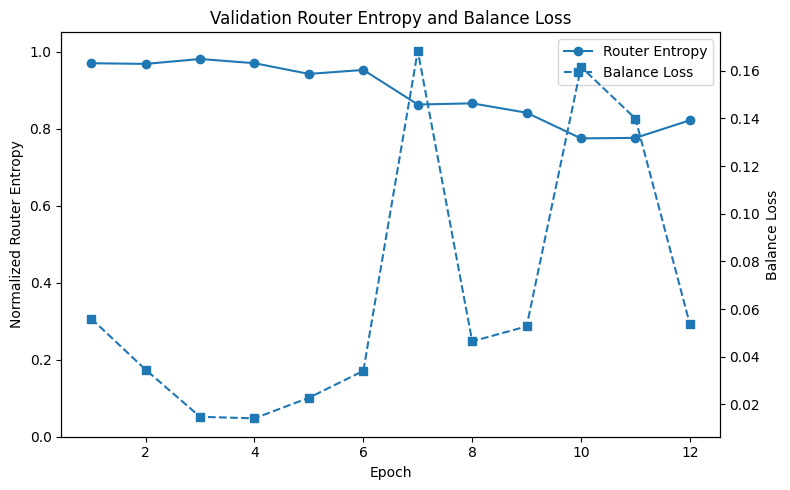

In [44]:
MOE_ROUTING_CURVE_PATH = (
    OUTPUT_DIR
    / "moe_validation_routing_metrics.png"
)

fig, ax1 = plt.subplots(
    figsize=(8, 5)
)

ax1.plot(
    moe_history_df["epoch"],
    moe_history_df[
        "val_router_entropy"
    ],
    marker="o",
    label="Router Entropy",
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Normalized Router Entropy")
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()

ax2.plot(
    moe_history_df["epoch"],
    moe_history_df[
        "val_balance_loss"
    ],
    marker="s",
    linestyle="--",
    label="Balance Loss",
)

ax2.set_ylabel("Balance Loss")

lines_1, labels_1 = (
    ax1.get_legend_handles_labels()
)

lines_2, labels_2 = (
    ax2.get_legend_handles_labels()
)

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best",
)

plt.title(
    "Validation Router Entropy "
    "and Balance Loss"
)

fig.tight_layout()

plt.savefig(
    MOE_ROUTING_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

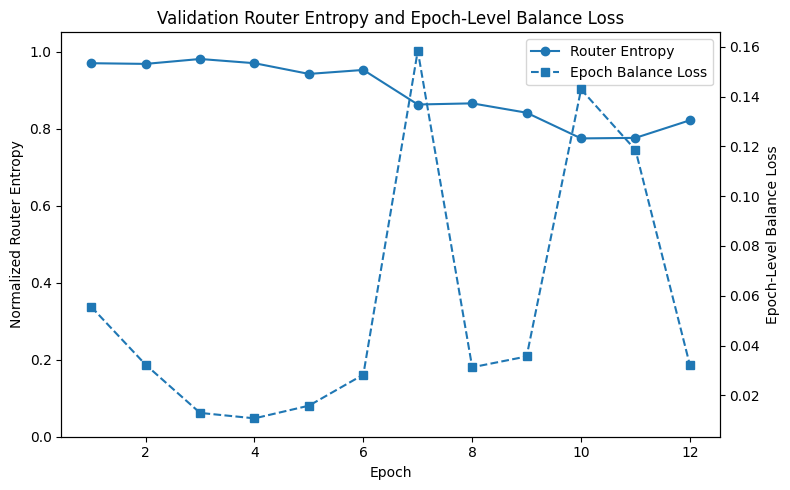

In [48]:
MOE_ROUTING_CURVE_PATH = (
    OUTPUT_DIR
    / "moe_validation_routing_metrics_epoch_level.png"
)

fig, ax1 = plt.subplots(
    figsize=(8, 5)
)

ax1.plot(
    moe_history_df["epoch"],
    moe_history_df[
        "val_router_entropy"
    ],
    marker="o",
    label="Router Entropy",
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel(
    "Normalized Router Entropy"
)
ax1.set_ylim(0, 1.05)

ax2 = ax1.twinx()

ax2.plot(
    moe_history_df["epoch"],
    moe_history_df[
        "val_epoch_balance_loss"
    ],
    marker="s",
    linestyle="--",
    label="Epoch Balance Loss",
)

ax2.set_ylabel(
    "Epoch-Level Balance Loss"
)

lines_1, labels_1 = (
    ax1.get_legend_handles_labels()
)

lines_2, labels_2 = (
    ax2.get_legend_handles_labels()
)

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best",
)

plt.title(
    "Validation Router Entropy "
    "and Epoch-Level Balance Loss"
)

fig.tight_layout()

plt.savefig(
    MOE_ROUTING_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# **Evaluation of Sparse Top-2 MoE**

## **Loading the best checkpoint**

In [49]:
import math

best_moe_checkpoint = torch.load(
    BEST_MOE_PATH,
    map_location=DEVICE,
    weights_only=False,
)

moe_student.load_state_dict(
    best_moe_checkpoint[
        "model_state_dict"
    ],
    strict=True,
)

moe_student = moe_student.to(DEVICE)
moe_student.eval()

print(
    "Loaded best epoch:",
    best_moe_checkpoint["epoch"],
)

print(
    "Loaded best validation AUC:",
    f"{best_moe_checkpoint['best_val_auc']:.4f}",
)

print(
    "Saved validation metrics:"
)

display(
    pd.DataFrame(
        [
            best_moe_checkpoint[
                "val_metrics"
            ]
        ]
    ).round(4)
)

Loaded best epoch: 8
Loaded best validation AUC: 0.7524
Saved validation metrics:


,total_loss,bce_loss,balance_loss,router_entropy,roc_auc,average_precision,accuracy,balanced_accuracy,precision,sensitivity,...,tn,fp,fn,tp,expert_0_usage,expert_0_router_probability,expert_1_usage,expert_1_router_probability,expert_2_usage,expert_2_router_probability
0,0.6511,0.6507,0.0464,0.8656,0.7524,0.7034,0.6763,0.6753,0.6463,0.662,...,230,104,97,190,0.2794,0.3614,0.368,0.2513,0.3527,0.3873


## **Gathering predictions and routing information**

In [50]:
def get_batch_metadata(
    batch,
    possible_keys,
    batch_size,
):
    for key in possible_keys:
        if key in batch:
            values = batch[key]

            return [
                str(value)
                for value in values
            ]

    return [None] * batch_size

In [51]:
@torch.inference_mode()
def collect_moe_predictions(
    model,
    data_loader,
    device,
):
    model.eval()

    prediction_rows = []

    progress_bar = tqdm(
        data_loader,
        desc="Collecting MoE predictions",
        leave=False,
    )

    for batch in progress_bar:
        images = batch["images"].to(
            device,
            non_blocking=True,
        )

        labels = (
            batch["labels"]
            .detach()
            .cpu()
            .numpy()
            .astype(np.int64)
            .reshape(-1)
        )

        batch_size = len(labels)

        image_paths = get_batch_metadata(
            batch=batch,
            possible_keys=[
                "path",
                "image_path",
            ],
            batch_size=batch_size,
        )

        patient_ids = get_batch_metadata(
            batch=batch,
            possible_keys=[
                "patient",
                "patient_id",
            ],
            batch_size=batch_size,
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            output = model(images)

        logits = (
            output["logits"]
            .view(-1)
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        probabilities = (
            torch.sigmoid(
                output["logits"].view(-1)
            )
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        expert_logits = (
            output["expert_logits"]
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        router_probabilities = (
            output["router_probabilities"]
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        sparse_gates = (
            output["sparse_gates"]
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        topk_indices = (
            output["topk_indices"]
            .detach()
            .cpu()
            .numpy()
        )

        topk_weights = (
            output["sparse_gates"]
            .gather(
                dim=1,
                index=output[
                    "topk_indices"
                ],
            )
            .detach()
            .float()
            .cpu()
            .numpy()
        )

        normalized_entropy = (
            -np.sum(
                router_probabilities
                * np.log(
                    np.clip(
                        router_probabilities,
                        1e-8,
                        1.0,
                    )
                ),
                axis=1,
            )
            / math.log(model.num_experts)
        )

        for sample_index in range(
            batch_size
        ):
            row = {
                "image_path": (
                    image_paths[sample_index]
                ),
                "patient_id": (
                    patient_ids[sample_index]
                ),
                "label": int(
                    labels[sample_index]
                ),
                "logit": float(
                    logits[sample_index]
                ),
                "probability": float(
                    probabilities[sample_index]
                ),
                "router_entropy": float(
                    normalized_entropy[
                        sample_index
                    ]
                ),
                "top1_expert": int(
                    topk_indices[
                        sample_index, 0
                    ]
                ),
                "top2_expert": int(
                    topk_indices[
                        sample_index, 1
                    ]
                ),
                "top1_gate": float(
                    topk_weights[
                        sample_index, 0
                    ]
                ),
                "top2_gate": float(
                    topk_weights[
                        sample_index, 1
                    ]
                ),
            }

            for expert_index in range(
                model.num_experts
            ):
                row[
                    f"expert_{expert_index}_logit"
                ] = float(
                    expert_logits[
                        sample_index,
                        expert_index,
                    ]
                )

                row[
                    f"expert_{expert_index}_router_probability"
                ] = float(
                    router_probabilities[
                        sample_index,
                        expert_index,
                    ]
                )

                row[
                    f"expert_{expert_index}_sparse_gate"
                ] = float(
                    sparse_gates[
                        sample_index,
                        expert_index,
                    ]
                )

            prediction_rows.append(row)

    return pd.DataFrame(
        prediction_rows
    )

In [52]:
moe_val_prediction_df = (
    collect_moe_predictions(
        model=moe_student,
        data_loader=student_val_loader,
        device=DEVICE,
    )
)

print(
    "Validation predictions:",
    len(moe_val_prediction_df),
)

display(
    moe_val_prediction_df.head()
)

assert len(
    moe_val_prediction_df
) == 621

assert (
    moe_val_prediction_df["label"]
    .nunique()
    == 2
)

assert (
    moe_val_prediction_df[
        "probability"
    ]
    .between(0, 1)
    .all()
)

assert np.allclose(
    moe_val_prediction_df[
        [
            "expert_0_sparse_gate",
            "expert_1_sparse_gate",
            "expert_2_sparse_gate",
        ]
    ].sum(axis=1),
    1.0,
    atol=1e-4,
)

print(
    "MoE prediction and routing "
    "collection verified."
)

Validation predictions: 621


,image_path,patient_id,label,logit,probability,router_entropy,top1_expert,top2_expert,top1_gate,top2_gate,expert_0_logit,expert_0_router_probability,expert_0_sparse_gate,expert_1_logit,expert_1_router_probability,expert_1_sparse_gate,expert_2_logit,expert_2_router_probability,expert_2_sparse_gate
0,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01510,0,-1.064331,0.256483,0.980416,2,1,0.568551,0.431449,-0.538086,0.254909,0.000000,-0.585449,0.321469,0.431449,-1.427734,0.423622,0.568551
1,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00281,0,1.223131,0.772614,0.939800,0,1,0.675015,0.324985,1.574219,0.510152,0.675015,0.493896,0.245612,0.324985,0.177612,0.244236,0.000000
2,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00008,0,-1.096552,0.250387,0.974590,2,1,0.581266,0.418734,-0.257568,0.246385,0.000000,-0.522949,0.315564,0.418734,-1.509766,0.438051,0.581266
3,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_00078,1,-0.286498,0.428861,0.998771,2,0,0.515239,0.484761,0.037476,0.333490,0.484761,-0.057556,0.312054,0.000000,-0.591309,0.354457,0.515239
4,cbis_ddsm_awsaf/jpeg/1.3.6.1.4.1.9590.100.1.2....,P_01395,0,0.837852,0.698013,0.977853,0,2,0.588520,0.411480,1.675781,0.435579,0.588520,0.134155,0.259874,0.000000,-0.360596,0.304547,0.411480


MoE prediction and routing collection verified.


## **ROC-AUC, PR-AUC, and Average Precision**

In [53]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    auc,
    average_precision_score,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

In [54]:
moe_val_labels = (
    moe_val_prediction_df["label"]
    .to_numpy()
    .astype(np.int64)
)

moe_val_probabilities = (
    moe_val_prediction_df[
        "probability"
    ]
    .to_numpy()
    .astype(np.float64)
)


(
    moe_fpr,
    moe_tpr,
    moe_roc_thresholds,
) = roc_curve(
    moe_val_labels,
    moe_val_probabilities,
)

moe_roc_auc = auc(
    moe_fpr,
    moe_tpr,
)


(
    moe_precision_curve,
    moe_recall_curve,
    moe_pr_thresholds,
) = precision_recall_curve(
    moe_val_labels,
    moe_val_probabilities,
)

moe_pr_auc = auc(
    moe_recall_curve,
    moe_precision_curve,
)

moe_average_precision = (
    average_precision_score(
        moe_val_labels,
        moe_val_probabilities,
    )
)


print(
    "MoE validation ROC-AUC:",
    f"{moe_roc_auc:.4f}",
)

print(
    "MoE validation PR-AUC :",
    f"{moe_pr_auc:.4f}",
)

print(
    "MoE Average Precision :",
    f"{moe_average_precision:.4f}",
)

assert np.isclose(
    moe_roc_auc,
    best_moe_checkpoint[
        "best_val_auc"
    ],
    atol=1e-4,
)

MoE validation ROC-AUC: 0.7524
MoE validation PR-AUC : 0.7025
MoE Average Precision : 0.7034


## **Determining the Youden threshold**

In [55]:
moe_youden_j = (
    moe_tpr - moe_fpr
)

finite_threshold_mask = np.isfinite(
    moe_roc_thresholds
)

valid_youden_values = np.where(
    finite_threshold_mask,
    moe_youden_j,
    -np.inf,
)

moe_best_threshold_index = int(
    np.argmax(
        valid_youden_values
    )
)

moe_optimal_threshold = float(
    moe_roc_thresholds[
        moe_best_threshold_index
    ]
)

moe_optimal_sensitivity = float(
    moe_tpr[
        moe_best_threshold_index
    ]
)

moe_optimal_specificity = float(
    1.0
    - moe_fpr[
        moe_best_threshold_index
    ]
)

moe_max_youden_j = float(
    moe_youden_j[
        moe_best_threshold_index
    ]
)

print(
    "MoE optimal threshold:",
    f"{moe_optimal_threshold:.4f}",
)

print(
    "Sensitivity:",
    f"{moe_optimal_sensitivity:.4f}",
)

print(
    "Specificity:",
    f"{moe_optimal_specificity:.4f}",
)

print(
    "Youden's J:",
    f"{moe_max_youden_j:.4f}",
)

MoE optimal threshold: 0.3496
Sensitivity: 0.7909
Specificity: 0.6108
Youden's J: 0.4017


## **Comparison of a threshold of 0.5 and the Youden index**

In [56]:
moe_metrics_threshold_05 = (
    calculate_binary_metrics(
        labels=moe_val_labels,
        probabilities=(
            moe_val_probabilities
        ),
        threshold=0.5,
    )
)

moe_metrics_youden = (
    calculate_binary_metrics(
        labels=moe_val_labels,
        probabilities=(
            moe_val_probabilities
        ),
        threshold=(
            moe_optimal_threshold
        ),
    )
)


moe_threshold_comparison_df = (
    pd.DataFrame(
        [
            {
                "threshold_type": (
                    "Default 0.5"
                ),
                "threshold": 0.5,
                **moe_metrics_threshold_05,
            },
            {
                "threshold_type": (
                    "Youden optimal"
                ),
                "threshold": (
                    moe_optimal_threshold
                ),
                **moe_metrics_youden,
            },
        ]
    )
)

display(
    moe_threshold_comparison_df.round(4)
)

,threshold_type,threshold,roc_auc,average_precision,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Default 0.5,0.5000,0.7524,0.7034,0.6763,0.6753,0.6463,0.6620,0.6886,0.654,230,104,97,190
1,Youden optimal,0.3496,0.7524,0.7034,0.6940,0.7009,0.6359,0.7909,0.6108,0.705,204,130,60,227


## **Classification report and confusion matrix**

In [57]:
moe_youden_predictions = (
    moe_val_probabilities
    >= moe_optimal_threshold
).astype(np.int64)


print(
    classification_report(
        moe_val_labels,
        moe_youden_predictions,
        target_names=[
            "Benign",
            "Malignant",
        ],
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Benign     0.7727    0.6108    0.6823       334
   Malignant     0.6359    0.7909    0.7050       287

    accuracy                         0.6940       621
   macro avg     0.7043    0.7009    0.6936       621
weighted avg     0.7095    0.6940    0.6928       621



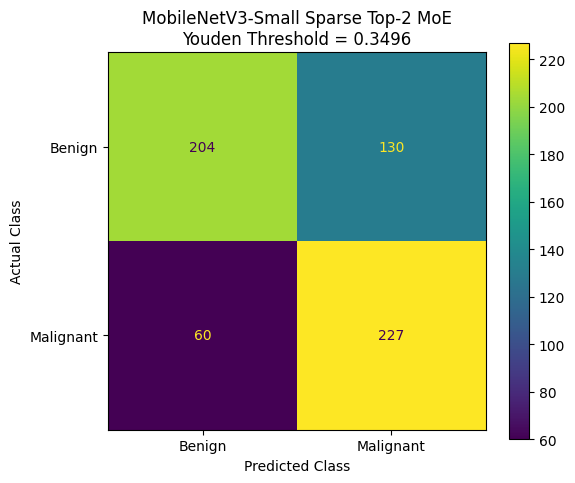

In [58]:
MOE_CONFUSION_MATRIX_PATH = (
    OUTPUT_DIR
    / "moe_validation_confusion_matrix.png"
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay.from_predictions(
    moe_val_labels,
    moe_youden_predictions,
    display_labels=[
        "Benign",
        "Malignant",
    ],
    values_format="d",
    ax=ax,
)

ax.set_title(
    "MobileNetV3-Small Sparse Top-2 MoE\n"
    f"Youden Threshold = "
    f"{moe_optimal_threshold:.4f}"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    MOE_CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## **ROC Curve and Precision–Recall**

**ROC Curve**

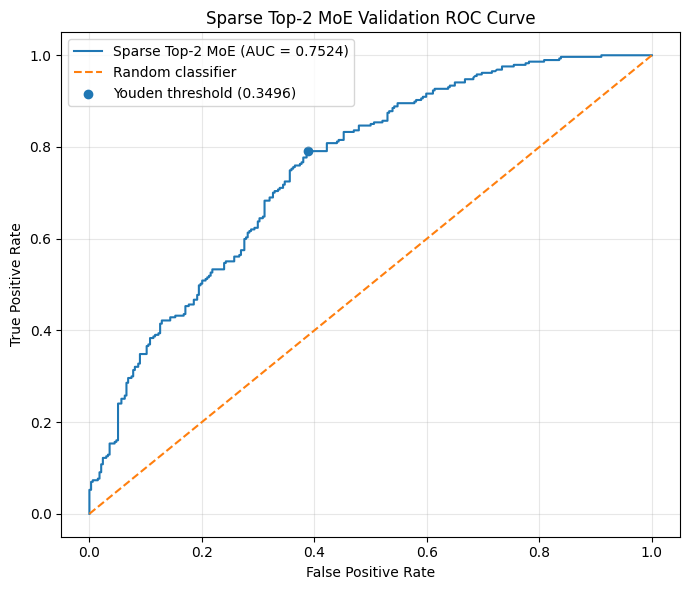

In [59]:
MOE_ROC_CURVE_PATH = (
    OUTPUT_DIR
    / "moe_validation_roc_curve.png"
)

plt.figure(figsize=(7, 6))

plt.plot(
    moe_fpr,
    moe_tpr,
    label=(
        f"Sparse Top-2 MoE "
        f"(AUC = {moe_roc_auc:.4f})"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.scatter(
    moe_fpr[
        moe_best_threshold_index
    ],
    moe_tpr[
        moe_best_threshold_index
    ],
    label=(
        "Youden threshold "
        f"({moe_optimal_threshold:.4f})"
    ),
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Sparse Top-2 MoE Validation ROC Curve"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    MOE_ROC_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

**Precision-Recall Curve**

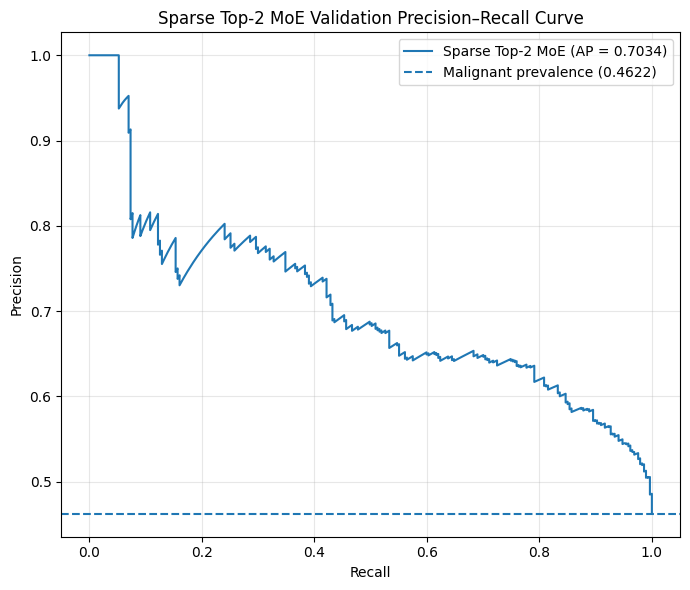

In [60]:
MOE_PR_CURVE_PATH = (
    OUTPUT_DIR
    / "moe_validation_precision_recall_curve.png"
)

malignant_prevalence = float(
    moe_val_labels.mean()
)

plt.figure(figsize=(7, 6))

plt.plot(
    moe_recall_curve,
    moe_precision_curve,
    label=(
        f"Sparse Top-2 MoE "
        f"(AP = "
        f"{moe_average_precision:.4f})"
    ),
)

plt.axhline(
    malignant_prevalence,
    linestyle="--",
    label=(
        "Malignant prevalence "
        f"({malignant_prevalence:.4f})"
    ),
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Sparse Top-2 MoE Validation "
    "Precision–Recall Curve"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    MOE_PR_CURVE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# **Best checkpoint routing analysis**

## **Global routing statistics**

In [61]:
moe_router_probability_columns = [
    f"expert_{expert_index}"
    "_router_probability"
    for expert_index in range(3)
]

moe_router_probability_means = (
    moe_val_prediction_df[
        moe_router_probability_columns
    ]
    .mean(axis=0)
    .to_numpy()
)


moe_expert_selection_counts = (
    np.zeros(
        3,
        dtype=np.int64,
    )
)

for expert_index in range(3):
    moe_expert_selection_counts[
        expert_index
    ] = int(
        (
            moe_val_prediction_df[
                "top1_expert"
            ]
            == expert_index
        ).sum()
        +
        (
            moe_val_prediction_df[
                "top2_expert"
            ]
            == expert_index
        ).sum()
    )


moe_expert_usage = (
    moe_expert_selection_counts
    / (
        len(moe_val_prediction_df)
        * moe_student.top_k
    )
)


moe_epoch_balance_loss = float(
    moe_student.num_experts
    * np.sum(
        moe_router_probability_means ** 2
    )
    - 1.0
)


moe_mean_router_entropy = float(
    moe_val_prediction_df[
        "router_entropy"
    ].mean()
)


moe_routing_summary_df = (
    pd.DataFrame(
        {
            "expert": [
                "Expert 0",
                "Expert 1",
                "Expert 2",
            ],
            "mean_router_probability": (
                moe_router_probability_means
            ),
            "selection_count": (
                moe_expert_selection_counts
            ),
            "hard_top2_usage": (
                moe_expert_usage
            ),
        }
    )
)


display(
    moe_routing_summary_df.round(6)
)

print(
    "Mean router entropy:",
    f"{moe_mean_router_entropy:.6f}",
)

print(
    "Epoch-level balance loss:",
    f"{moe_epoch_balance_loss:.6f}",
)

print(
    "Usage sum:",
    f"{moe_expert_usage.sum():.6f}",
)

assert np.isclose(
    moe_expert_usage.sum(),
    1.0,
    atol=1e-6,
)

assert np.isclose(
    moe_router_probability_means.sum(),
    1.0,
    atol=1e-5,
)

,expert,mean_router_probability,selection_count,hard_top2_usage
0,Expert 0,0.361440,347,0.279388
1,Expert 1,0.251278,457,0.367955
2,Expert 2,0.387282,438,0.352657


Mean router entropy: 0.865594
Epoch-level balance loss: 0.031301
Usage sum: 1.000000


## **Routing analysis by class**

In [62]:
routing_by_class_rows = []

for class_label, class_name in [
    (0, "Benign"),
    (1, "Malignant"),
]:
    class_df = (
        moe_val_prediction_df[
            moe_val_prediction_df[
                "label"
            ]
            == class_label
        ]
    )

    total_class_selections = (
        len(class_df)
        * moe_student.top_k
    )

    for expert_index in range(3):
        selection_count = int(
            (
                class_df["top1_expert"]
                == expert_index
            ).sum()
            +
            (
                class_df["top2_expert"]
                == expert_index
            ).sum()
        )

        routing_by_class_rows.append(
            {
                "class_label": class_label,
                "class_name": class_name,
                "expert": (
                    f"Expert {expert_index}"
                ),
                "sample_count": int(
                    len(class_df)
                ),
                "selection_count": (
                    selection_count
                ),
                "hard_top2_usage": float(
                    selection_count
                    / total_class_selections
                ),
                "mean_router_probability": float(
                    class_df[
                        f"expert_"
                        f"{expert_index}"
                        "_router_probability"
                    ].mean()
                ),
                "mean_sparse_gate": float(
                    class_df[
                        f"expert_"
                        f"{expert_index}"
                        "_sparse_gate"
                    ].mean()
                ),
            }
        )


moe_routing_by_class_df = (
    pd.DataFrame(
        routing_by_class_rows
    )
)

display(
    moe_routing_by_class_df.round(4)
)

,class_label,class_name,expert,sample_count,selection_count,hard_top2_usage,mean_router_probability,mean_sparse_gate
0,0,Benign,Expert 0,334,128,0.1916,0.2742,0.2405
1,0,Benign,Expert 1,334,256,0.3832,0.2564,0.2335
2,0,Benign,Expert 2,334,284,0.4251,0.4694,0.5260
3,1,Malignant,Expert 0,287,219,0.3815,0.4630,0.5171
4,1,Malignant,Expert 1,287,201,0.3502,0.2453,0.2016
5,1,Malignant,Expert 2,287,154,0.2683,0.2917,0.2813


## **Frequency of Top-2 pairs**

In [63]:
moe_expert_pair_df = (
    moe_val_prediction_df[
        [
            "top1_expert",
            "top2_expert",
        ]
    ]
    .copy()
)

moe_expert_pair_df[
    "expert_pair"
] = moe_expert_pair_df.apply(
    lambda row: "-".join(
        map(
            str,
            sorted(
                [
                    int(
                        row[
                            "top1_expert"
                        ]
                    ),
                    int(
                        row[
                            "top2_expert"
                        ]
                    ),
                ]
            ),
        )
    ),
    axis=1,
)

moe_pair_frequency_df = (
    moe_expert_pair_df[
        "expert_pair"
    ]
    .value_counts()
    .rename_axis(
        "expert_pair"
    )
    .reset_index(
        name="sample_count"
    )
)

moe_pair_frequency_df[
    "fraction"
] = (
    moe_pair_frequency_df[
        "sample_count"
    ]
    / len(
        moe_expert_pair_df
    )
)

display(
    moe_pair_frequency_df.round(4)
)

,expert_pair,sample_count,fraction
0,1-2,274,0.4412
1,0-1,183,0.2947
2,0-2,164,0.2641


# **Save Results**

## **Save all evaluation results**

In [64]:
MOE_PREDICTION_PATH = (
    OUTPUT_DIR
    / "moe_validation_predictions.csv"
)

MOE_THRESHOLD_COMPARISON_PATH = (
    OUTPUT_DIR
    / "moe_threshold_comparison.csv"
)

MOE_ROUTING_SUMMARY_PATH = (
    OUTPUT_DIR
    / "moe_validation_routing_summary.csv"
)

MOE_ROUTING_BY_CLASS_PATH = (
    OUTPUT_DIR
    / "moe_validation_routing_by_class.csv"
)

MOE_PAIR_FREQUENCY_PATH = (
    OUTPUT_DIR
    / "moe_validation_expert_pair_frequency.csv"
)

MOE_EVALUATION_SUMMARY_PATH = (
    OUTPUT_DIR
    / "moe_evaluation_summary.json"
)

In [65]:
moe_val_prediction_df[
    "prediction_threshold_05"
] = (
    moe_val_probabilities >= 0.5
).astype(np.int64)

moe_val_prediction_df[
    "prediction_youden"
] = (
    moe_val_probabilities
    >= moe_optimal_threshold
).astype(np.int64)


moe_val_prediction_df.to_csv(
    MOE_PREDICTION_PATH,
    index=False,
)

moe_threshold_comparison_df.to_csv(
    MOE_THRESHOLD_COMPARISON_PATH,
    index=False,
)

moe_routing_summary_df.to_csv(
    MOE_ROUTING_SUMMARY_PATH,
    index=False,
)

moe_routing_by_class_df.to_csv(
    MOE_ROUTING_BY_CLASS_PATH,
    index=False,
)

moe_pair_frequency_df.to_csv(
    MOE_PAIR_FREQUENCY_PATH,
    index=False,
)

In [66]:
moe_evaluation_summary = {
    "model": (
        "MobileNetV3-Small "
        "Sparse Top-2 MoE"
    ),
    "training_stage": (
        "sparse_moe_without_kd"
    ),
    "best_epoch": int(
        best_moe_checkpoint["epoch"]
    ),
    "validation_samples": int(
        len(moe_val_labels)
    ),
    "validation_roc_auc": float(
        moe_roc_auc
    ),
    "validation_pr_auc_trapezoidal": float(
        moe_pr_auc
    ),
    "validation_average_precision": float(
        moe_average_precision
    ),
    "default_threshold": 0.5,
    "youden_threshold": float(
        moe_optimal_threshold
    ),
    "youden_j": float(
        moe_max_youden_j
    ),
    "metrics_threshold_05": (
        moe_metrics_threshold_05
    ),
    "metrics_youden_threshold": (
        moe_metrics_youden
    ),
    "routing": {
        "num_experts": int(
            moe_student.num_experts
        ),
        "top_k": int(
            moe_student.top_k
        ),
        "expert_usage": [
            float(value)
            for value
            in moe_expert_usage
        ],
        "mean_router_probabilities": [
            float(value)
            for value
            in moe_router_probability_means
        ],
        "mean_router_entropy": float(
            moe_mean_router_entropy
        ),
        "epoch_balance_loss": float(
            moe_epoch_balance_loss
        ),
    },
    "total_parameters": int(
        moe_total_parameters
    ),
    "baseline_validation_roc_auc": (
        0.7716
    ),
    "roc_auc_difference_from_baseline": float(
        moe_roc_auc - 0.7716
    ),
    "teacher_validation_roc_auc": (
        0.7284107742702747
    ),
    "roc_auc_difference_from_teacher": float(
        moe_roc_auc
        - 0.7284107742702747
    ),
}

In [67]:
with open(
    MOE_EVALUATION_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        moe_evaluation_summary,
        file,
        indent=2,
    )


print("Predictions      :", MOE_PREDICTION_PATH)
print("Threshold table  :", MOE_THRESHOLD_COMPARISON_PATH)
print("Routing summary  :", MOE_ROUTING_SUMMARY_PATH)
print("Routing by class :", MOE_ROUTING_BY_CLASS_PATH)
print("Expert pairs     :", MOE_PAIR_FREQUENCY_PATH)
print("Evaluation JSON  :", MOE_EVALUATION_SUMMARY_PATH)

Predictions      : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/moe_validation_predictions.csv
Threshold table  : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/moe_threshold_comparison.csv
Routing summary  : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/moe_validation_routing_summary.csv
Routing by class : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/moe_validation_routing_by_class.csv
Expert pairs     : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/moe_validation_expert_pair_frequency.csv
Evaluation JSON  : /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/moe_evaluation_summary.json


# **Comparison with the baseline**

## **Baseline versus Sparse MoE Table**

In [68]:
BASELINE_SUMMARY_PATH = (
    DRIVE_PROJECT_ROOT
    / "outputs"
    / "student_mobilenetv3_small_baseline"
    / "baseline_evaluation_summary.json"
)


if BASELINE_SUMMARY_PATH.exists():
    with open(
        BASELINE_SUMMARY_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        baseline_summary = json.load(
            file
        )

    baseline_youden_metrics = (
        baseline_summary[
            "metrics_youden_threshold"
        ]
    )

    moe_youden_metrics = (
        moe_evaluation_summary[
            "metrics_youden_threshold"
        ]
    )

    baseline_moe_comparison_df = (
        pd.DataFrame(
            [
                {
                    "model": (
                        "MobileNetV3-Small "
                        "Baseline"
                    ),
                    "parameters": int(
                        baseline_summary[
                            "total_parameters"
                        ]
                    ),
                    "roc_auc": float(
                        baseline_summary[
                            "validation_roc_auc"
                        ]
                    ),
                    "pr_auc": float(
                        baseline_summary[
                            "validation_pr_auc_trapezoidal"
                        ]
                    ),
                    "average_precision": float(
                        baseline_summary[
                            "validation_average_precision"
                        ]
                    ),
                    "youden_threshold": float(
                        baseline_summary[
                            "youden_threshold"
                        ]
                    ),
                    "accuracy": float(
                        baseline_youden_metrics[
                            "accuracy"
                        ]
                    ),
                    "balanced_accuracy": float(
                        baseline_youden_metrics[
                            "balanced_accuracy"
                        ]
                    ),
                    "precision": float(
                        baseline_youden_metrics[
                            "precision"
                        ]
                    ),
                    "sensitivity": float(
                        baseline_youden_metrics[
                            "sensitivity"
                        ]
                    ),
                    "specificity": float(
                        baseline_youden_metrics[
                            "specificity"
                        ]
                    ),
                    "f1": float(
                        baseline_youden_metrics[
                            "f1"
                        ]
                    ),
                },
                {
                    "model": (
                        "MobileNetV3-Small "
                        "Sparse Top-2 MoE"
                    ),
                    "parameters": int(
                        moe_total_parameters
                    ),
                    "roc_auc": float(
                        moe_roc_auc
                    ),
                    "pr_auc": float(
                        moe_pr_auc
                    ),
                    "average_precision": float(
                        moe_average_precision
                    ),
                    "youden_threshold": float(
                        moe_optimal_threshold
                    ),
                    "accuracy": float(
                        moe_youden_metrics[
                            "accuracy"
                        ]
                    ),
                    "balanced_accuracy": float(
                        moe_youden_metrics[
                            "balanced_accuracy"
                        ]
                    ),
                    "precision": float(
                        moe_youden_metrics[
                            "precision"
                        ]
                    ),
                    "sensitivity": float(
                        moe_youden_metrics[
                            "sensitivity"
                        ]
                    ),
                    "specificity": float(
                        moe_youden_metrics[
                            "specificity"
                        ]
                    ),
                    "f1": float(
                        moe_youden_metrics[
                            "f1"
                        ]
                    ),
                },
            ]
        )
    )

    display(
        baseline_moe_comparison_df.round(4)
    )

    BASELINE_MOE_COMPARISON_PATH = (
        OUTPUT_DIR
        / "baseline_vs_sparse_moe.csv"
    )

    baseline_moe_comparison_df.to_csv(
        BASELINE_MOE_COMPARISON_PATH,
        index=False,
    )

    print(
        "Comparison saved:",
        BASELINE_MOE_COMPARISON_PATH,
    )

else:
    print(
        "Baseline evaluation summary "
        "was not found:"
    )

    print(
        BASELINE_SUMMARY_PATH
    )

,model,parameters,roc_auc,pr_auc,average_precision,youden_threshold,accuracy,balanced_accuracy,precision,sensitivity,specificity,f1
0,MobileNetV3-Small Baseline,927585,0.7716,0.7420,0.7435,0.5166,0.7021,0.6968,0.6977,0.6272,0.7665,0.6606
1,MobileNetV3-Small Sparse Top-2 MoE,1223206,0.7524,0.7025,0.7034,0.3496,0.6940,0.7009,0.6359,0.7909,0.6108,0.7050


Comparison saved: /content/drive/MyDrive/Research/outputs/student_mobilenetv3_small_sparse_top2_moe/baseline_vs_sparse_moe.csv
